# GraphQA Data Generator Guide

This notebook demonstrates how to use the GraphQA data generator to create graph reasoning problems and datasets for LLMs.

In [1]:
from data.graphqa.data_generator import graph_generators, graph_tasks, graph_text_encoders
import networkx as nx
import random

## 1. Generating Graphs

The data generator provides multiple graph generation algorithms:
- **ER (Erdős–Rényi)**: Random graphs with edges added probabilistically
- **BA (Barabási–Albert)**: Scale-free networks using preferential attachment
- **SBM (Stochastic Block Model)**: Graphs with community structure
- **SFN (Scale-Free Network)**: Another scale-free network model
- **Complete**: Fully connected graphs

You can generate directed or undirected graphs.

In [2]:
# Example 1: Generate graphs using different algorithms
num_graphs = 5

# Generate Erdős–Rényi graphs (undirected)
er_graphs = graph_generators.generate_graphs(
    number_of_graphs=num_graphs,
    algorithm="er",
    directed=False,
    random_seed=42,
    er_min_sparsity=0.2,
    er_max_sparsity=0.8
)

print(f"Generated {len(er_graphs)} ER graphs")
print(f"First graph: {len(er_graphs[0].nodes())} nodes, {len(er_graphs[0].edges())} edges")

# Generate Barabási–Albert graphs (directed)
ba_graphs = graph_generators.generate_graphs(
    number_of_graphs=num_graphs,
    algorithm="ba",
    directed=True,
    random_seed=42
)

print(f"\nGenerated {len(ba_graphs)} BA graphs (directed)")
print(f"First graph: {len(ba_graphs[0].nodes())} nodes, {len(ba_graphs[0].edges())} edges")

Generated 5 ER graphs
First graph: 14 nodes, 58 edges

Generated 5 BA graphs (directed)
First graph: 14 nodes, 24 edges


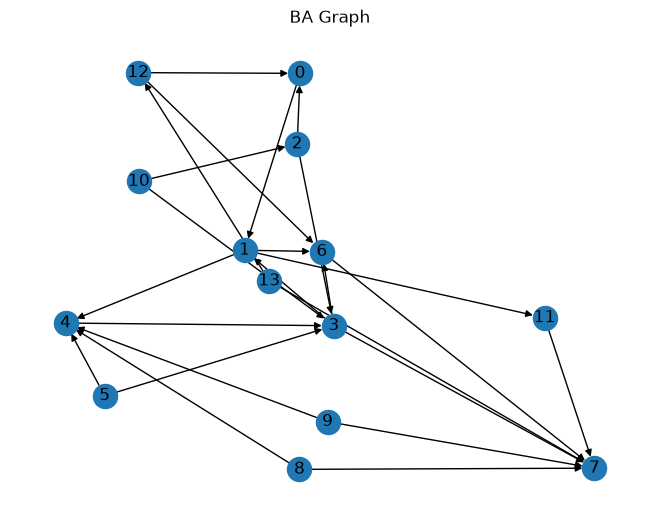

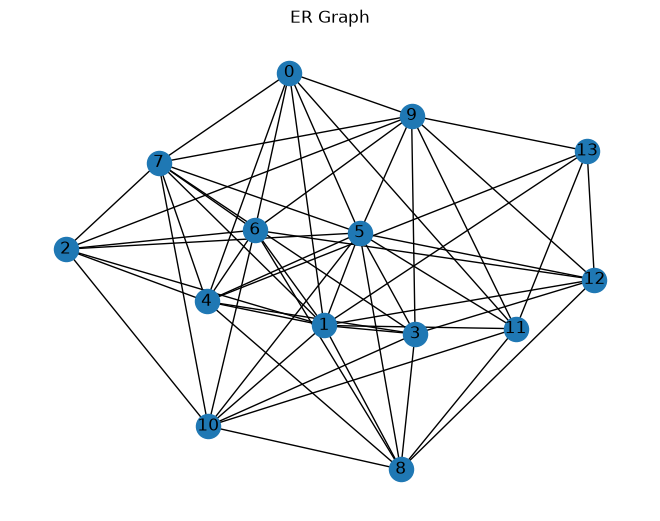

In [18]:
# show the first graph of each type with networkx drawing

import matplotlib.pyplot as plt

# Assuming `graphs` is a dictionary with graph types as keys and lists of graphs as values
for ba, er in zip(ba_graphs, er_graphs):
    
    nx.draw(ba, with_labels=True)
    plt.title("BA Graph")
    plt.show()

    nx.draw(er, with_labels=True)
    plt.title("ER Graph")
    plt.show()

    break


## 2. Graph Encoding Methods

Graphs can be encoded as text in different formats for LLMs:
- **adjacency**: Simple adjacency matrix notation (i, j) pairs
- **nx**: NetworkX format with edge types
- **friendship**: Natural language describing relationships as friendships
- **coauthorship**: Natural language describing relationships as coauthorships
- **nlg_extended**: Extended natural language generation
- **tlag**: "Talk Like A Graph" format from the paper

In [9]:
# Example 2: Encode graphs in different text formats
graph = er_graphs[0]

# Get node naming dictionary
node_dict = {i: f"Node{i}" for i in graph.nodes()}

# Try different encoding methods
print("=== ADJACENCY ENCODING ===")
adjacency_text = graph_text_encoders.adjacency_encoder(graph, node_dict)
print(adjacency_text)

print("\n=== FRIENDSHIP ENCODING ===")
friendship_text = graph_text_encoders.friendship_encoder(graph, node_dict)
print(friendship_text)

=== ADJACENCY ENCODING ===
In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes Node0, Node1, Node2, Node3, Node4, Node5, Node6, Node7, Node8, Node9, Node10, Node11, Node12, and Node13.
The edges in G are: (Node0, Node1) (Node0, Node4) (Node0, Node5) (Node0, Node6) (Node0, Node7) (Node0, Node9) (Node0, Node11) (Node1, Node2) (Node1, Node3) (Node1, Node4) (Node1, Node5) (Node1, Node6) (Node1, Node7) (Node1, Node8) (Node1, Node10) (Node1, Node11) (Node1, Node12) (Node1, Node13) (Node2, Node4) (Node2, Node5) (Node2, Node6) (Node2, Node7) (Node2, Node9) (Node2, Node10) (Node3, Node4) (Node3, Node5) (Node3, Node7) (Node3, Node8) (Node3, Node9) (Node3, Node10) (Node3, Node12) (Node4, Node5) (Node4, Node6) (Node4, Node7) (Node4, Node8) (Node4, Node13) (Node5, Node7) (Node5, Node8) (Node5, Node9) (Node5, Node10) (Node5, Node11) (Node5, Node12) (Node6, Node7) (Node6, Node8) (Node6, Node9) (Node6, Node10) (Node6, Node12

## 3. Graph Tasks

Available graph reasoning tasks:
- **edge_existence**: Does an edge exist between two nodes?
- **node_degree**: What is the degree of a node?
- **node_count**: How many nodes in the graph?
- **edge_count**: How many edges in the graph?
- **connected_nodes**: Find all nodes connected to a given node
- **disconnected_nodes**: Find nodes not connected to a given node
- **cycle_check**: Is there a cycle in the graph?
- **reachability**: Can node A reach node B?
- **shortest_path**: What is the shortest path between nodes?
- **maximum_flow**: What is the maximum flow?
- **node_classification**: Classification task
- **triangle_counting**: Count triangles in the graph

In [10]:
# Example 3: Create graph tasks
# Use CycleCheck as an example
cycle_task = graph_tasks.CycleCheck()

print(f"Task name: {cycle_task.name}")
print(f"Task description: {cycle_task._task_description}")

# Prepare examples using the graphs and encoding method
examples_dict = cycle_task.prepare_examples_dict(
    graphs=er_graphs,
    generator_algorithms=["er"] * len(er_graphs),
    encoding_method="adjacency"
)

# Display first example
first_example = examples_dict[0]
print(f"\n=== FIRST EXAMPLE ===")
print(f"Question:\n{first_example['question']}\n")
print(f"Answer: {first_example['answer']}")
print(f"Graph size: {first_example['nnodes']} nodes, {first_example['nedges']} edges")

Task name: cycle_check
Task description: Q: Is there a cycle in this graph?
A: 

=== FIRST EXAMPLE ===
Question:
In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, and 13.
The edges in G are: (0, 1) (0, 4) (0, 5) (0, 6) (0, 7) (0, 9) (0, 11) (1, 2) (1, 3) (1, 4) (1, 5) (1, 6) (1, 7) (1, 8) (1, 10) (1, 11) (1, 12) (1, 13) (2, 4) (2, 5) (2, 6) (2, 7) (2, 9) (2, 10) (3, 4) (3, 5) (3, 7) (3, 8) (3, 9) (3, 10) (3, 12) (4, 5) (4, 6) (4, 7) (4, 8) (4, 13) (5, 7) (5, 8) (5, 9) (5, 10) (5, 11) (5, 12) (6, 7) (6, 8) (6, 9) (6, 10) (6, 12) (7, 9) (7, 10) (8, 10) (8, 11) (8, 12) (9, 11) (9, 12) (9, 13) (10, 11) (11, 13) (12, 13).
Q: Is there a cycle in this graph?
A: 

Answer: Yes, there is a cycle.
Graph size: 14 nodes, 58 edges


## 4. Few-Shot Examples with Chain-of-Thought

You can generate few-shot examples with or without Chain-of-Thought (CoT) reasoning:

In [11]:
# Example 4: Create few-shot examples with CoT
# Without Chain-of-Thought
few_shot_example_zero_cot = cycle_task.create_few_shot_example(
    graph=er_graphs[0],
    encoding_method="adjacency",
    cot=False
)

print("=== FEW-SHOT EXAMPLE (NO CoT) ===")
print(few_shot_example_zero_cot)

# With Chain-of-Thought
few_shot_example_with_cot = cycle_task.create_few_shot_example(
    graph=er_graphs[0],
    encoding_method="adjacency",
    cot=True
)

print("\n\n=== FEW-SHOT EXAMPLE (WITH CoT) ===")
print(few_shot_example_with_cot)

=== FEW-SHOT EXAMPLE (NO CoT) ===
In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, and 13.
The edges in G are: (0, 1) (0, 4) (0, 5) (0, 6) (0, 7) (0, 9) (0, 11) (1, 2) (1, 3) (1, 4) (1, 5) (1, 6) (1, 7) (1, 8) (1, 10) (1, 11) (1, 12) (1, 13) (2, 4) (2, 5) (2, 6) (2, 7) (2, 9) (2, 10) (3, 4) (3, 5) (3, 7) (3, 8) (3, 9) (3, 10) (3, 12) (4, 5) (4, 6) (4, 7) (4, 8) (4, 13) (5, 7) (5, 8) (5, 9) (5, 10) (5, 11) (5, 12) (6, 7) (6, 8) (6, 9) (6, 10) (6, 12) (7, 9) (7, 10) (8, 10) (8, 11) (8, 12) (9, 11) (9, 12) (9, 13) (10, 11) (11, 13) (12, 13).
Q: Is there a cycle in this graph?
A: Yes, there is a cycle. 


=== FEW-SHOT EXAMPLE (WITH CoT) ===
In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, and 13.
The edges in G are: (0, 1) (0, 4) (0, 5) (0, 6) (0, 

## 5. Complete Workflow Summary

Here's a typical workflow for generating a GraphQA dataset:

1. **Generate graphs** using `graph_generators.generate_graphs()`
2. **Create task instances** (e.g., `CycleCheck()`, `Reachability()`, etc.)
3. **Prepare examples** using `task.prepare_examples_dict()` with your chosen encoding method
4. **Generate few-shot examples** using `task.create_few_shot_example()` for prompting
5. **Format and save** the examples for use with LLMs

The available encoding methods are: `adjacency`, `nx`, `friendship`, `coauthorship`, `nlg_extended`, `tlag`

The available algorithms are: `er`, `ba`, `sbm`, `sfn`, `complete`